### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics

In [55]:
import tensorflow as tf
from tensorflow.keras import layers, Model

In [46]:
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Data

In [4]:
df = pd.read_csv('./data/Dataset--Heart-Disease-Prediction-using-ANN.csv')

In [5]:
df.shape

(303, 14)

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Step 3: Exploaring Data

Basic Info

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [23]:
feature_info = pd.DataFrame(
        {'Null': df.isnull().sum(), 'Unique': df.nunique(), 'Dtype': df.dtypes}
    )

In [24]:
feature_info

,Null,Unique,Dtype
age,0,41,int64
sex,0,2,int64
cp,0,4,int64
trestbps,0,49,int64
chol,0,152,int64
fbs,0,2,int64
restecg,0,3,int64
thalach,0,91,int64
exang,0,2,int64
oldpeak,0,40,float64


Target Distribution

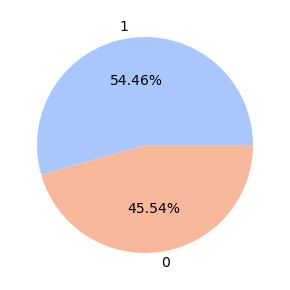

In [13]:
temp = df['target'].value_counts()
plt.figure(figsize=(3, 3))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index,
    colors=sns.color_palette('coolwarm', 2)
)
plt.tight_layout()

Int Distribution

In [30]:
int_cols = feature_info[(feature_info['Dtype'] == 'int64') & (feature_info['Unique'] <= 4)].index.to_list()
int_cols.remove('target')

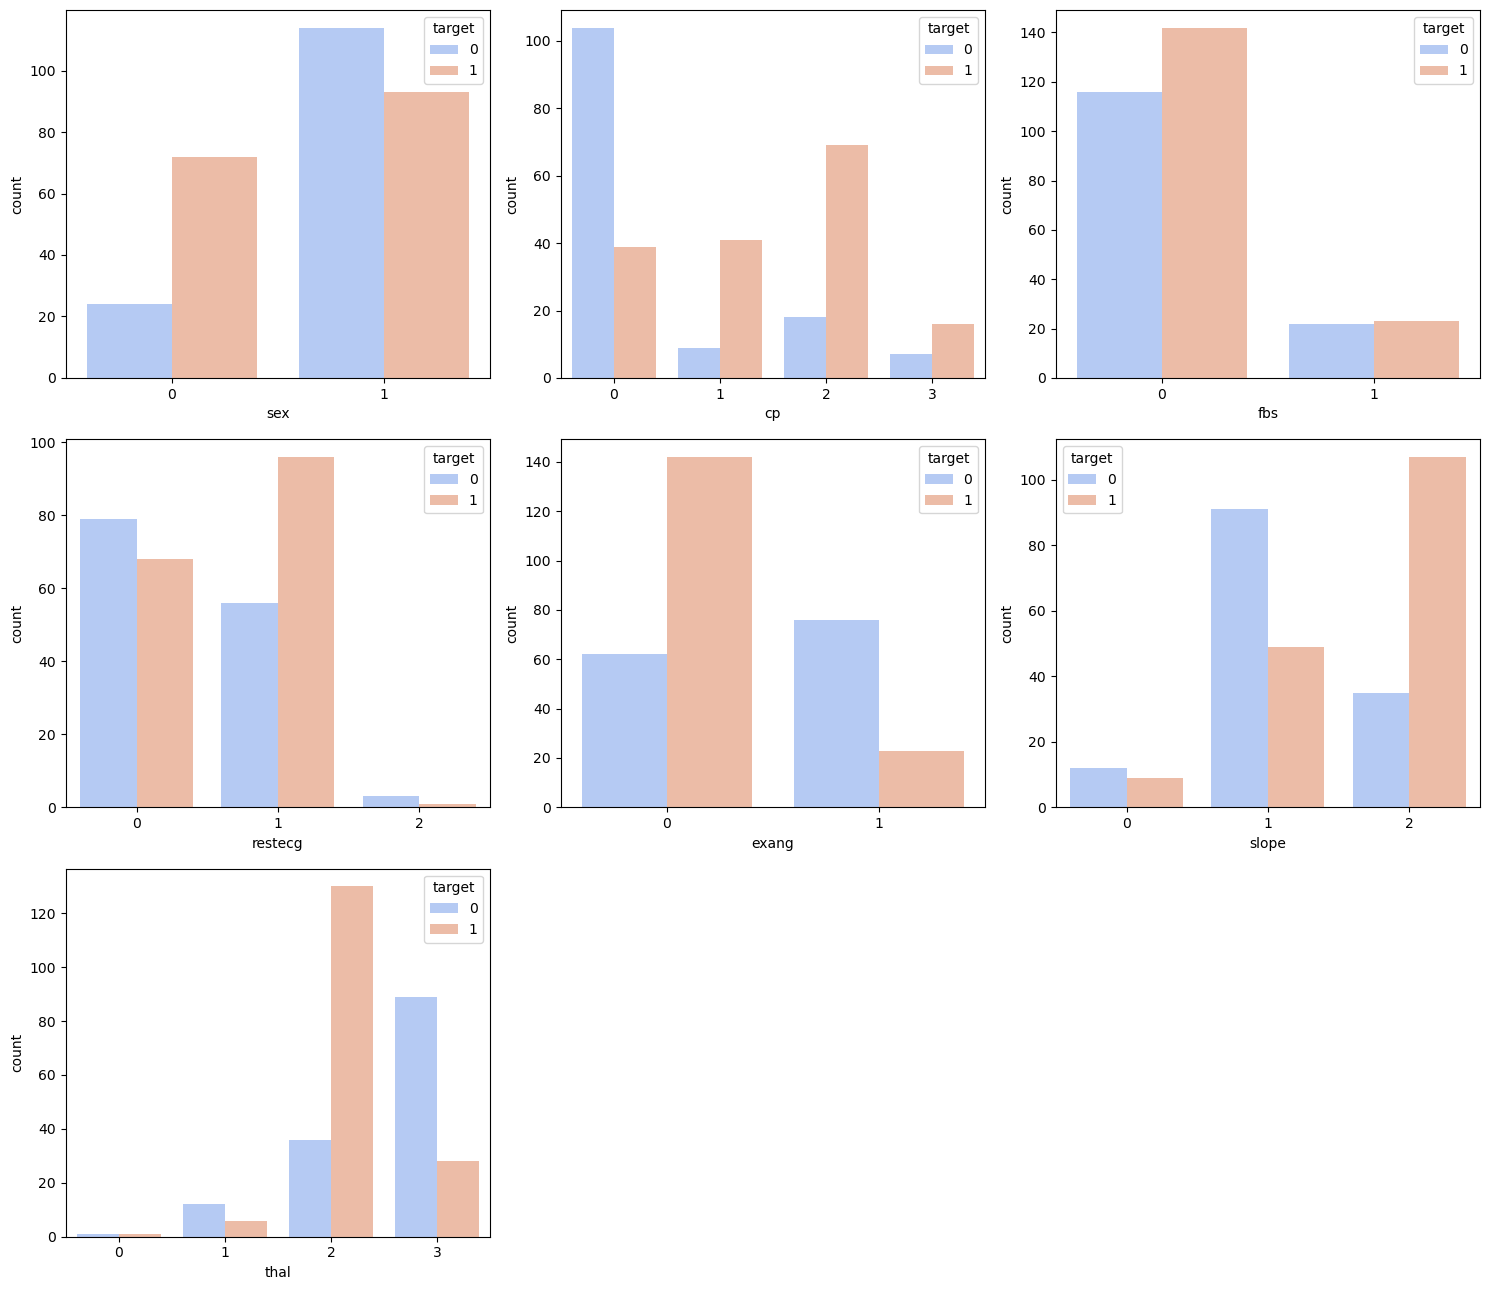

In [33]:
plt.figure(figsize=(15, 13))
for i, col in enumerate(int_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(
        x=col,
        hue='target',
        data=df,
        palette='coolwarm'
    )
plt.tight_layout()

Float Distribution

In [34]:
float_cols = feature_info[feature_info['Dtype'] == 'float64'].index.to_list()

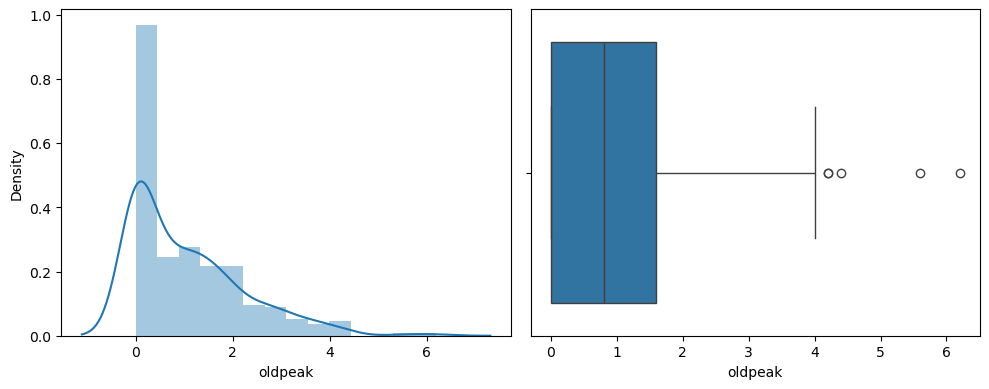

In [42]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.distplot(df['oldpeak'])
plt.subplot(1, 2, 2)
sns.boxplot(df['oldpeak'], orient='h')
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Value

In [43]:
df.dropna(ignore_index=True, inplace=True)

Heat Map

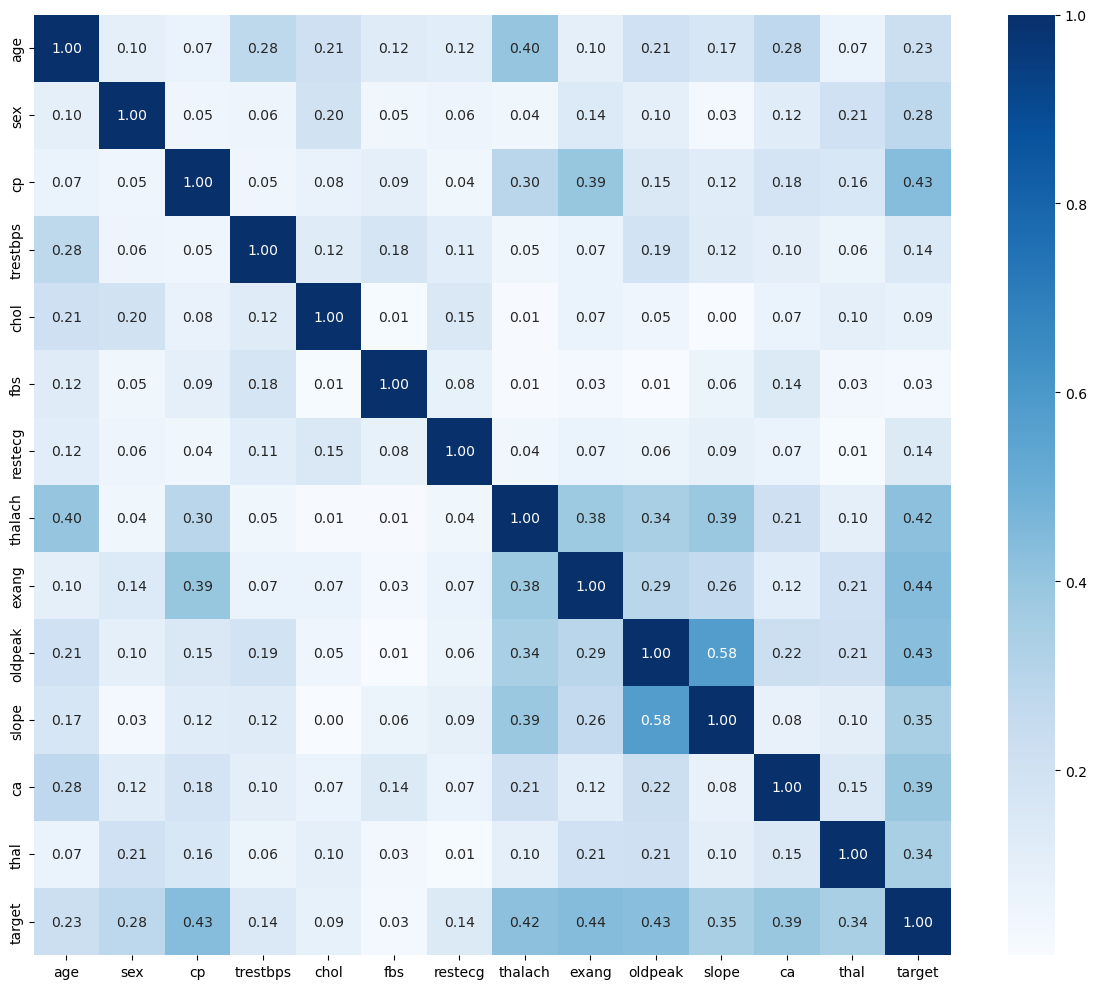

In [45]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    annot=True,
    fmt='.2f',
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

Select Features

In [48]:
features = df.drop('target', axis=1)
target = df['target']

In [47]:
selector = SmartCorrelatedSelection(threshold=0.8, selection_method='corr_with_target')

In [49]:
features = selector.fit_transform(features, target)

In [50]:
print(f'Current Number of Feature is {features.shape[1]}')

Current Number of Feature is 13


Split Data

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Normalization

In [53]:
scaler = StandardScaler()

In [54]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

In [104]:
inputs = layers.Input(shape=(13,))
x = layers.Dense(units=8, activation='relu', kernel_initializer='uniform')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(units=14, activation='relu', kernel_initializer='uniform')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(units=1, activation='sigmoid', kernel_initializer='uniform')(x)

In [105]:
model = Model(inputs, outputs)

In [106]:
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 8)                   │             112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 8)                   │              32 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 14)                  │             126 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 14)                  │              56 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 14)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 1)                   │              15 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 341 (1.33 KB)

 Trainable params: 297 (1.16 KB)

 Non-trainable params: 44 (176.00 B)

In [107]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [108]:
history = model.fit(
    X_train,
    y_train,
    batch_size=8,
    epochs=100,
    validation_data=(X_test, y_test)
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5702 - loss: 0.6760 - val_accuracy: 0.5246 - val_loss: 0.6924
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6777 - loss: 0.6282 - val_accuracy: 0.5246 - val_loss: 0.6899
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8264 - loss: 0.5535 - val_accuracy: 0.5246 - val_loss: 0.6832
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8017 - loss: 0.5157 - val_accuracy: 0.7049 - val_loss: 0.6713
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8140 - loss: 0.5149 - val_accuracy: 0.8033 - val_loss: 0.6574
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7851 - loss: 0.5011 - val_accuracy: 0.8689 - val_loss: 0.6403
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8017 - loss: 0.4842 - val_accuracy: 0.8852 - val_loss: 0.6215
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8017 - loss: 0.4758 - val_accuracy: 0.8852 - v

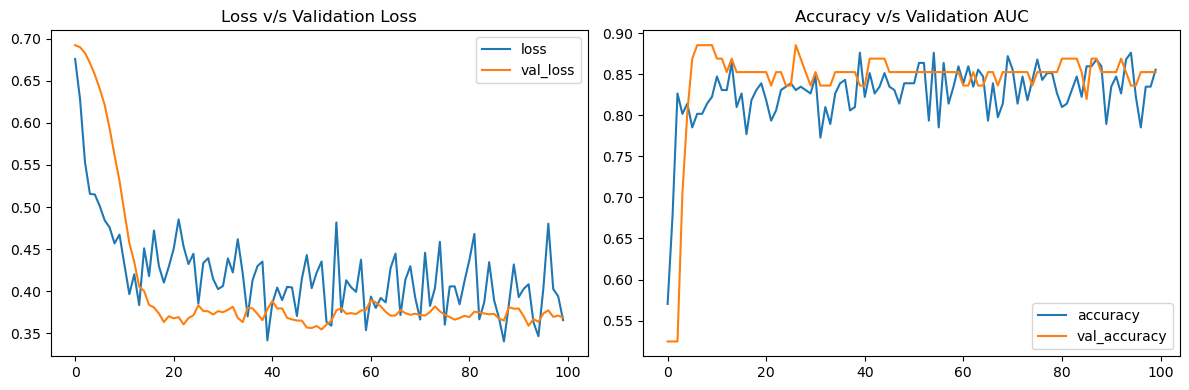

In [110]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss v/s Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy v/s Validation AUC')
plt.legend()

plt.tight_layout()

In [111]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [112]:
y_pred = y_pred > 0.5

In [113]:
cm = metrics.confusion_matrix(y_test, y_pred)

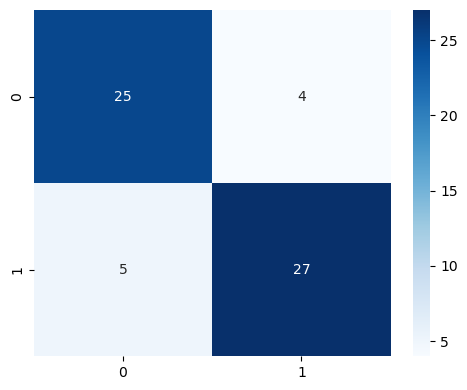

In [116]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=plt.cm.Blues
)
plt.tight_layout()

In [114]:
accuracy = (cm[0][0]+cm[1][1])/(cm[0][1] + cm[1][0] +cm[0][0] +cm[1][1])
print(accuracy*100)

85.24590163934425
